In [1]:
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

plt.style.use("ggplot")

print("Libraries Loaded")

Matplotlib is building the font cache; this may take a moment.


Libraries Loaded


In [3]:
TRAIN_DIR = "../data/raw/NEU-DET/train/images"
VAL_DIR = "../data/raw/NEU-DET/validation/images"

classes = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print(classes)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [5]:
train_counts = {}
val_counts = {}

for cls in classes:

    train_path = os.path.join(TRAIN_DIR, cls)
    val_path = os.path.join(VAL_DIR, cls)

    train_counts[cls] = len([
        f for f in os.listdir(train_path)
        if f.endswith(".jpg")
    ])

    val_counts[cls] = len([
        f for f in os.listdir(val_path)
        if f.endswith(".jpg")
    ])

df_counts = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts
})

df_counts

,Train,Validation
crazing,240,60
inclusion,240,60
patches,240,60
pitted_surface,240,60
rolled-in_scale,240,60
scratches,240,60


In [6]:
total_train = sum(train_counts.values())
total_val = sum(val_counts.values())

print(f"Train Images      : {total_train}")
print(f"Validation Images : {total_val}")
print(f"Total Images      : {total_train + total_val}")

Train Images      : 1440
Validation Images : 360
Total Images      : 1800


<Figure size 1000x500 with 0 Axes>

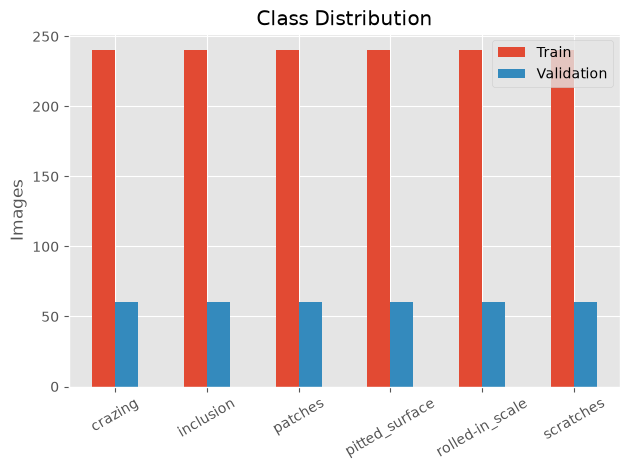

In [8]:
plt.figure(figsize=(10,5))

df_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.ylabel("Images")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("../figures/class_distribution.png")

plt.show()

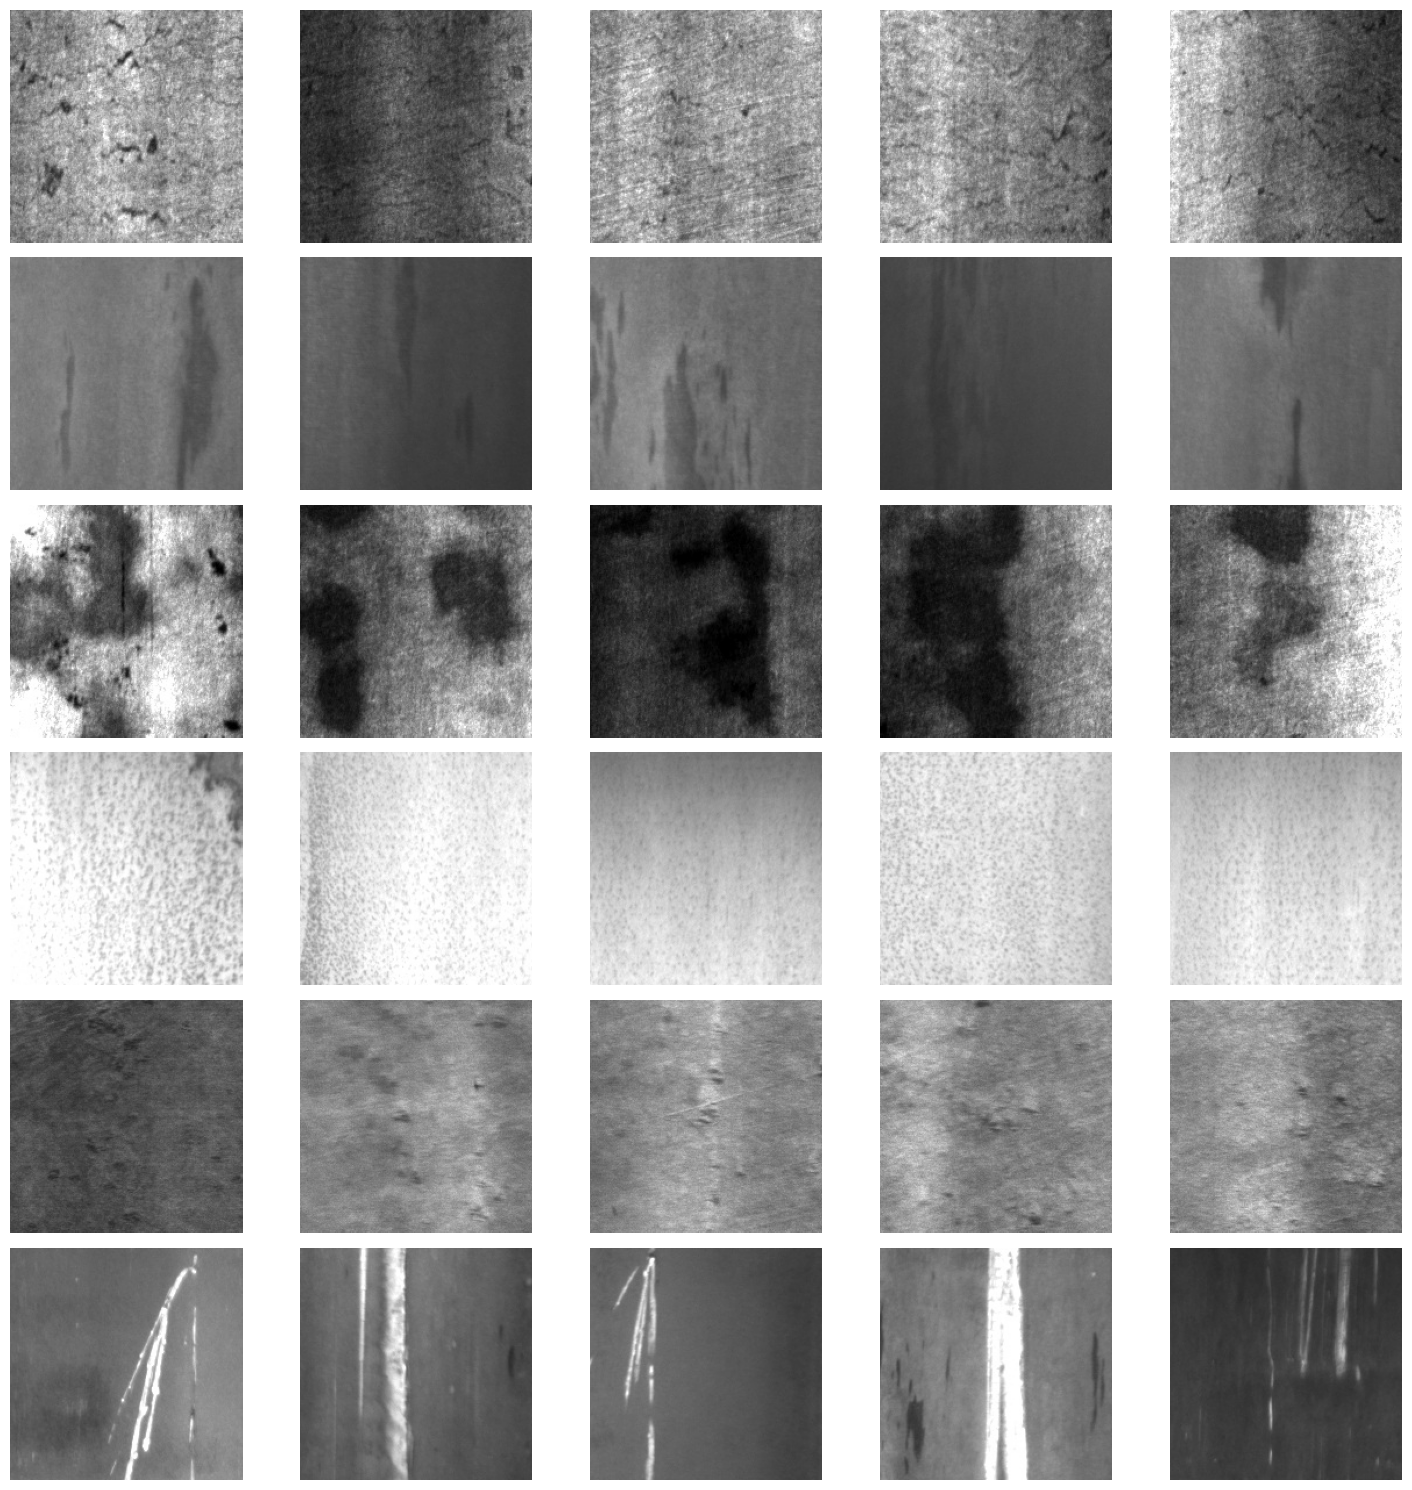

In [9]:
fig, axes = plt.subplots(
    len(classes),
    5,
    figsize=(15,15)
)

for row, cls in enumerate(classes):

    folder = os.path.join(TRAIN_DIR, cls)

    images = np.random.choice(
        os.listdir(folder),
        5,
        replace=False
    )

    for col, image_name in enumerate(images):

        img = cv2.imread(
            os.path.join(folder, image_name)
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        axes[row,col].imshow(img)
        axes[row,col].axis("off")

        if col == 0:
            axes[row,col].set_ylabel(
                cls,
                rotation=0,
                labelpad=50
            )

plt.tight_layout()

plt.savefig("../figures/sample_grid.png")

plt.show()

In [10]:
heights = []
widths = []

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    for file in os.listdir(folder):

        img = cv2.imread(
            os.path.join(folder, file)
        )

        h, w = img.shape[:2]

        heights.append(h)
        widths.append(w)

print("Unique Heights:", np.unique(heights))
print("Unique Widths :", np.unique(widths))

Unique Heights: [200]
Unique Widths : [200]


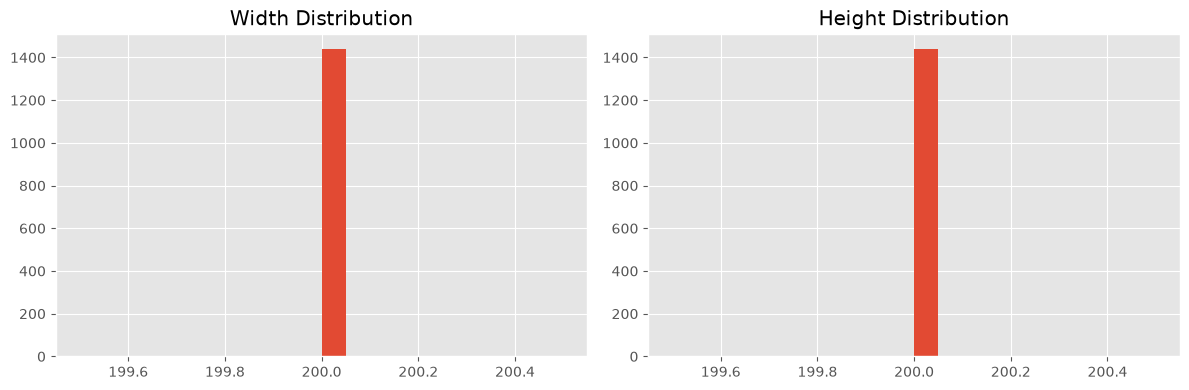

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(widths,bins=20)
plt.title("Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights,bins=20)
plt.title("Height Distribution")

plt.tight_layout()

plt.show()

In [12]:
pixel_sum = 0
pixel_sq_sum = 0
pixel_count = 0

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    for file in os.listdir(folder):

        img = cv2.imread(
            os.path.join(folder,file),
            cv2.IMREAD_GRAYSCALE
        )

        img = img / 255.0

        pixel_sum += np.sum(img)
        pixel_sq_sum += np.sum(img**2)

        pixel_count += img.size

mean = pixel_sum / pixel_count

std = np.sqrt(
    pixel_sq_sum/pixel_count - mean**2
)

print("Mean:", mean)
print("Std :", std)

Mean: 0.5049536186002177
Std : 0.2083267012645405


In [13]:
brightness = {}

for cls in classes:

    values = []

    folder = os.path.join(TRAIN_DIR, cls)

    for file in os.listdir(folder):

        img = cv2.imread(
            os.path.join(folder,file),
            cv2.IMREAD_GRAYSCALE
        )

        values.append(
            img.mean()
        )

    brightness[cls] = np.mean(values)

brightness

{'crazing': np.float64(135.60468135416667),
 'inclusion': np.float64(101.84041614583333),
 'patches': np.float64(131.9128489583333),
 'pitted_surface': np.float64(178.8112057291667),
 'rolled-in_scale': np.float64(126.43274614583333),
 'scratches': np.float64(97.977138125)}

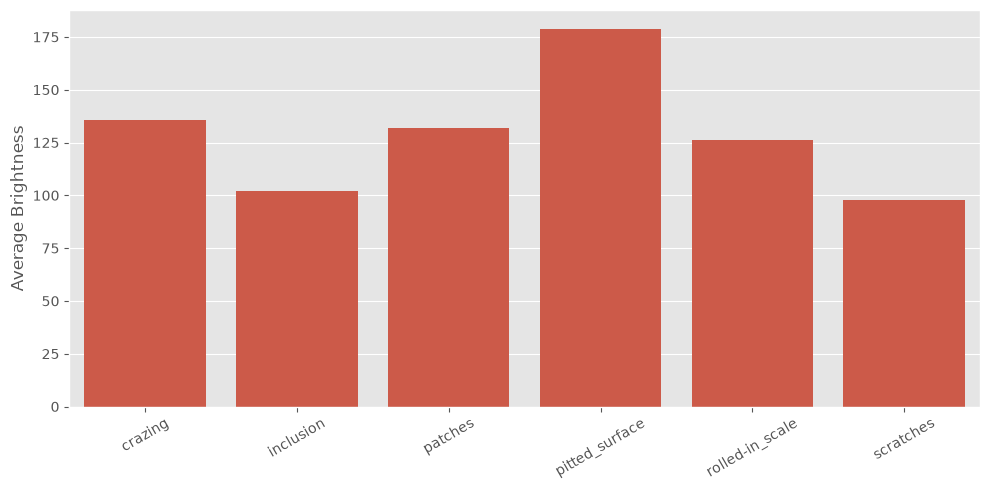

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=list(brightness.keys()),
    y=list(brightness.values())
)

plt.xticks(rotation=30)

plt.ylabel("Average Brightness")

plt.tight_layout()

plt.show()

In [15]:
texture_scores = []

for cls in classes:

    folder = os.path.join(TRAIN_DIR, cls)

    for file in os.listdir(folder):

        img = cv2.imread(
            os.path.join(folder,file),
            cv2.IMREAD_GRAYSCALE
        )

        score = cv2.Laplacian(
            img,
            cv2.CV_64F
        ).var()

        texture_scores.append(score)

print("Average Texture Score:",
      np.mean(texture_scores))

Average Texture Score: 761.8508453260121


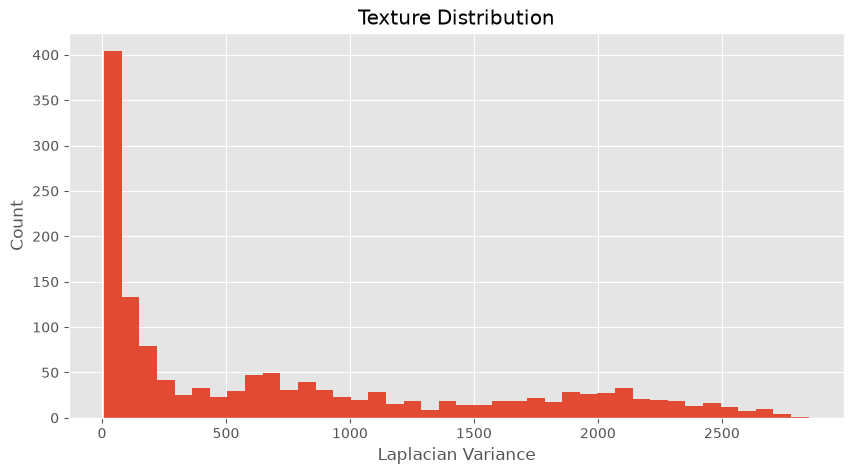

In [16]:
plt.figure(figsize=(10,5))

plt.hist(
    texture_scores,
    bins=40
)

plt.xlabel("Laplacian Variance")
plt.ylabel("Count")

plt.title("Texture Distribution")

plt.show()